# Visualization Quality Metrics: *Benchmark Data*

This notebook computes Trustworthiness, Continuity, Spearman Correlation, and DEMaP for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP, TriMAP, t-SNE) on benchmark datasets, for both `all-MiniLM-L6-v2` and `Qwen3-Embedding-0.6B` embeddings.

Embeddings are loaded from precomputed `.npy` files generated by `eval_pipeline.py`. 2D reductions are computed and cached in `cache/{embedding_model}_reduced_2d/`. Results are saved to `../results/viz_metrics/{provider}/`.

## Methodology

### Dimensionality Reduction
Six DR methods are evaluated, each applied directly to the high-dimensional sentence embeddings to produce 2D representations:

- **PCA**: Linear projection via SVD; components ordered by variance (scikit-learn).
- **UMAP**: Nonlinear manifold learning; preserves local neighborhood structure with `n_neighbors=10`, `min_dist=0.05` (McInnes et al., 2018).
- **PHATE**: Diffusion-based method designed for continuous and hierarchical structure (Moon et al., 2019).
- **PaCMAP**: Preserves both local and global structure via mid-near pair sampling (Wang et al., 2021).
- **TriMAP**: Uses triplet constraints to preserve global structure (Amid & Warmuth, 2019).
- **t-SNE**: Nonlinear method optimized for local cluster separation. Following standard practice (van der Maaten & Hinton, 2008), embeddings are first reduced to 50 dimensions with PCA before applying t-SNE, as recommended for high-dimensional input data.

### Visualization Quality Metrics
Four metrics are computed on the 2D reductions to quantify how well each method preserves the structure of the original embedding space:

- **Trustworthiness** (Venna & Kaski, 2001): Measures whether k-nearest neighbors in 2D were also neighbors in high-dim space (local structure). Range: [0, 1], higher is better.
- **Continuity** (Venna & Kaski, 2001): Measures whether k-nearest neighbors in high-dim space are preserved in 2D (reverse of trustworthiness). Range: [0, 1], higher is better.
- **Spearman Correlation**: Rank correlation of all pairwise Euclidean distances between high-dim and 2D (global structure). Range: [-1, 1], higher is better.
- **DEMaP** (Moon et al., 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D. Better captures true manifold geometry than raw Euclidean distances. The minimum K for a fully connected graph is used automatically.

### Caching
2D reductions are cached as `.npy` files in `cache/{embedding_model}_reduced_2d/`. Metrics are saved incrementally after each method completes to `../results/viz_metrics/{provider}/viz_metrics_{dataset}.csv`, allowing interrupted runs to resume without recomputation.

### References
- van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *JMLR*, 9, 2579–2605.
- McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform manifold approximation and projection. *arXiv:1802.03426*.
- Moon, K.R., et al. (2019). Visualizing structure and transitions in high-dimensional biological data. *Nature Biotechnology*, 37, 1482–1492.
- Wang, Y., et al. (2021). Understanding how dimension reduction tools work. *JMLR*, 22(201), 1–73.
- Amid, E., & Warmuth, M.K. (2019). TriMap: Large-scale dimensionality reduction using triplets. *arXiv:1910.00204*.
- Venna, J., & Kaski, S. (2001). Neighborhood preservation in nonlinear projection methods. *ICANN*, 485–491.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phate
import pacmap
import trimap
import umap as umap_pkg
from cuml.manifold import TSNE as cuTSNE
from sklearn.decomposition import PCA as skPCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# Navigate to src/ — walk up from notebook location until we find a dir containing src/
current = os.path.abspath('')
while not os.path.isdir(os.path.join(current, 'src')) and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = os.path.join(current, 'src')
os.chdir(src_dir)
sys.path.insert(0, src_dir)

## 1. Setup

Change `dataset` to run on a different benchmark. Available options: `rcv1`, `arxiv`, `amazon`, `dbpedia`, `wos`.

In [2]:
# config: change dataset and embedding model here
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
dataset = "rcv1"  # options: rcv1, arxiv, amazon, dbpedia, wos

provider      = embedding_model.split("/")[0]  # "sentence-transformers" or "Qwen"
cache_base    = "intermediate_data" if os.path.isdir("intermediate_data") else "cache"
embedding_dir = f"{cache_base}/{embedding_model}_embeddings"
results_dir   = f"../results/viz_metrics/{provider}"
shepard_dir   = f"../results/shepard_diagrams/{provider}"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(shepard_dir, exist_ok=True)

# subsampling config (mirrors viz_metrics_script.py)
SUBSAMPLE_THRESHOLD = 10_000   # use subsampling for datasets larger than this
SUBSAMPLE_SIZE      = 10_000   # points per subsample
N_SUBSAMPLES        = 30       # number of subsamples (mean ± std reported)

## 2. Load Embeddings

Load precomputed embeddings from `eval_pipeline.py` output. To generate these, run:

```bash
python src/run_models/benchmark_datasets/eval_pipeline.py --dataset rcv1
```

In [3]:
# load precomputed high-dimensional embeddings
x_high = np.load(f"{embedding_dir}/{dataset}.npy")
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (1566, 384)


## 3. Compute 2D Reductions

All six methods are run natively at 2D directly from the high-dimensional embeddings. PCA uses SVD (components ordered by variance). PHATE uses metric MDS with `n_components=2`. UMAP and PaCMAP are run at `n_components=2` — slicing the first 2 columns of a higher-dimensional embedding is not valid for these methods since they are optimization-based with no component ordering. t-SNE is applied to PCA-50 pre-reduced embeddings as is standard practice.

**Batch script** (`viz_metrics_script.py`): 2D reductions are computed on the **full dataset**. For large datasets (> 10,000 points), metrics are computed on 30 random subsamples of 10,000 points each (mean ± std reported). Results are cached in `{cache_base}/{embedding_model}_reduced_2d/` using the suffix `{dataset}_full{N}`.

**This notebook**: loads the cached full-dataset 2D files produced by the batch script. The cell below also supports recomputing from scratch on a 5,000-point subsample if the full cache is unavailable.

In [4]:
reduction_2d_dir = f"{cache_base}/{embedding_model}_reduced_2d"
os.makedirs(reduction_2d_dir, exist_ok=True)

# subsample before running 2D reductions — large datasets (e.g. amazon ~60k) are too slow otherwise
# pairwise distances in the metrics step also scale as n^2, so the same limit applies there
max_samples = 5000
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    sub_idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[sub_idx]
    print(f"Subsampled to {max_samples} points for 2D reduction and metrics")
else:
    x_high_sub = x_high
    print(f"No subsampling needed ({x_high.shape[0]} points)")

def load_or_compute_2d(name, path, compute_fn):
    if os.path.exists(path):
        print(f"Loading cached 2D {name} from {path}...")
        return np.load(path)
    print(f"Computing 2D {name}...")
    result = compute_fn()
    np.save(path, result)
    print(f"Saved to {path}")
    return result

suffix = f"{dataset}_full{x_high.shape[0]}"

# note: if the full cache is missing (e.g. running locally without HPCC files),
# change suffix to f"{dataset}_sub{len(x_high_sub)}" to recompute on the subsample

reductions = {}

reductions["PCA"] = load_or_compute_2d(
    "PCA", f"{reduction_2d_dir}/PCA_2d_{suffix}.npy",
    lambda: skPCA(n_components=2, random_state=67).fit_transform(x_high_sub)
)
reductions["UMAP"] = load_or_compute_2d(
    "UMAP", f"{reduction_2d_dir}/UMAP_2d_{suffix}.npy",
    lambda: umap_pkg.UMAP(n_components=2, min_dist=0.05, n_neighbors=10, random_state=67).fit_transform(x_high_sub)
)
reductions["PHATE"] = load_or_compute_2d(
    "PHATE", f"{reduction_2d_dir}/PHATE_2d_{suffix}.npy",
    lambda: phate.PHATE(n_jobs=-2, random_state=67, n_components=2).fit_transform(x_high_sub)
)
reductions["PaCMAP"] = load_or_compute_2d(
    "PaCMAP", f"{reduction_2d_dir}/PaCMAP_2d_{suffix}.npy",
    lambda: pacmap.PaCMAP(n_components=2, random_state=67).fit_transform(x_high_sub)
)
reductions["TriMAP"] = load_or_compute_2d(
    "TriMAP", f"{reduction_2d_dir}/TriMAP_2d_{suffix}.npy",
    lambda: trimap.TRIMAP(n_dims=2).fit_transform(x_high_sub)
)
reductions["tSNE"] = load_or_compute_2d(
    "tSNE", f"{reduction_2d_dir}/tSNE_2d_{suffix}.npy",
    lambda: np.array(cuTSNE(n_components=2).fit_transform(
        skPCA(n_components=50, random_state=67).fit_transform(x_high_sub)
    ))
)

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

No subsampling needed (1566 points)
Loading cached 2D PCA from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PCA_2d_rcv1_full1566.npy...
Loading cached 2D UMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/UMAP_2d_rcv1_full1566.npy...
Loading cached 2D PHATE from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PHATE_2d_rcv1_full1566.npy...
Loading cached 2D PaCMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PaCMAP_2d_rcv1_full1566.npy...
Loading cached 2D TriMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/TriMAP_2d_rcv1_full1566.npy...
Loading cached 2D tSNE from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/tSNE_2d_rcv1_full1566.npy...
PCA: (1566, 2)
UMAP: (1566, 2)
PHATE: (1566, 2)
PaCMAP: (1566, 2)
TriMAP: (1566, 2)
tSNE: (1566, 2)


## 4. Metrics

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)
- **Spearman Correlation**: rank correlation of raw pairwise Euclidean distances high-dim vs 2D
- **DEMaP** (Moon et al. 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D; better captures true manifold structure than raw Euclidean

Trustworthiness and Continuity range from 0 to 1, higher is better. Spearman and DEMaP range from -1 to 1, where 1 is perfect preservation and 0 means no relationship.

**Variability estimation**: For large datasets (> 10,000 points), metrics are computed on 30 random subsamples of 10,000 points and reported as mean ± std. For smaller datasets, a single computation is performed (std = 0).

In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]

    d_high = pairwise_distances(x_high)
    d_low  = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)

    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low  = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors

    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

In [6]:
def compute_demap(x_high, x_low_2d, k_min=3, k_max=15):
    # DEMaP: geodesic distances (k-NN shortest path) in high-dim vs Euclidean in 2D
    # Moon et al. 2019 (PHATE paper)
    # uses smallest K where the graph is fully connected (no inf geodesic distances)
    for k in range(k_min, k_max + 1):
        knn = kneighbors_graph(x_high, n_neighbors=k, mode='distance', include_self=False)
        geo = shortest_path(knn, directed=False)
        if not np.any(np.isinf(geo)):
            print(f"    DEMaP using K={k} (min connected)")
            break
    if np.any(np.isinf(geo)):
        max_finite = np.nanmax(geo[np.isfinite(geo)])
        geo[np.isinf(geo)] = 1 + max_finite

    idx = np.triu_indices(x_high.shape[0], k=1)
    geo_flat = geo[idx]
    euc_flat = pairwise_distances(x_low_2d)[idx]

    return spearmanr(geo_flat, euc_flat)[0]

In [7]:
def compute_metrics_once(x_high_sub, x_low_sub):
    t_score = trustworthiness(x_high_sub, x_low_sub, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_sub, n_neighbors=15)
    d_high_flat = pairwise_distances(x_high_sub).flatten()
    d_low_flat  = pairwise_distances(x_low_sub).flatten()
    spearman_corr, _ = spearmanr(d_high_flat, d_low_flat)
    demap_score = compute_demap(x_high_sub, x_low_sub)
    return t_score, c_score, spearman_corr, demap_score

# load cached metrics if available — skip already-computed methods
output_path = os.path.join(results_dir, f"viz_metrics_{dataset}.csv")
if os.path.exists(output_path):
    cached_df = pd.read_csv(output_path)
    cached_methods = set(cached_df["Method"].tolist())
    stats = cached_df.to_dict("records")
    print(f"Loaded cached metrics for: {cached_methods}")
else:
    cached_methods = set()
    stats = []

n_total = x_high_sub.shape[0]
use_subsampling = n_total > SUBSAMPLE_THRESHOLD

if use_subsampling:
    print(f"Dataset has {n_total} points — using {N_SUBSAMPLES}x subsamples of {SUBSAMPLE_SIZE} for metrics")
else:
    print(f"Dataset has {n_total} points — computing metrics on full subset (no subsampling needed)")

for name, x_low_2d in reductions.items():
    if name in cached_methods:
        print(f"Skipping {name} (already cached)")
        continue

    print(f"Computing metrics for {name}...")

    if use_subsampling:
        t_scores, c_scores, sp_scores, demap_scores = [], [], [], []
        for s in range(N_SUBSAMPLES):
            idx = np.random.choice(n_total, SUBSAMPLE_SIZE, replace=False)
            t, c, sp, dm = compute_metrics_once(x_high_sub[idx], x_low_2d[idx])
            t_scores.append(t); c_scores.append(c)
            sp_scores.append(sp); demap_scores.append(dm)
            if (s + 1) % 10 == 0:
                print(f"  subsample {s+1}/{N_SUBSAMPLES} done")

        stats.append({
            "Method":                   name,
            "Trustworthiness_mean":      round(np.mean(t_scores),     4),
            "Trustworthiness_std":       round(np.std(t_scores),      4),
            "Continuity_mean":           round(np.mean(c_scores),     4),
            "Continuity_std":            round(np.std(c_scores),      4),
            "Spearman_Correlation_mean": round(np.mean(sp_scores),    4),
            "Spearman_Correlation_std":  round(np.std(sp_scores),     4),
            "DEMaP_mean":                round(np.mean(demap_scores), 4),
            "DEMaP_std":                 round(np.std(demap_scores),  4),
            "n_subsamples":              N_SUBSAMPLES,
            "subsample_size":            SUBSAMPLE_SIZE,
        })
        print(f"{name}: T={np.mean(t_scores):.4f}±{np.std(t_scores):.4f}, "
              f"C={np.mean(c_scores):.4f}±{np.std(c_scores):.4f}, "
              f"Spearman={np.mean(sp_scores):.4f}±{np.std(sp_scores):.4f}, "
              f"DEMaP={np.mean(demap_scores):.4f}±{np.std(demap_scores):.4f}")
    else:
        t, c, sp, dm = compute_metrics_once(x_high_sub, x_low_2d)
        stats.append({
            "Method":                   name,
            "Trustworthiness_mean":      round(t,  4),
            "Trustworthiness_std":       0.0,
            "Continuity_mean":           round(c,  4),
            "Continuity_std":            0.0,
            "Spearman_Correlation_mean": round(sp, 4),
            "Spearman_Correlation_std":  0.0,
            "DEMaP_mean":                round(dm, 4),
            "DEMaP_std":                 0.0,
            "n_subsamples":              1,
            "subsample_size":            n_total,
        })
        print(f"{name}: T={t:.4f}, C={c:.4f}, Spearman={sp:.4f}, DEMaP={dm:.4f}")

    # save after each method (incremental caching)
    pd.DataFrame(stats).to_csv(output_path, index=False)
    print(f"  Saved to {output_path}")

pd.DataFrame(stats)

Loaded cached metrics for: {'PHATE', 'PCA', 'TriMAP', 'UMAP', 'tSNE', 'PaCMAP'}
Dataset has 1566 points — computing metrics on full subset (no subsampling needed)
Skipping PCA (already cached)
Skipping UMAP (already cached)
Skipping PHATE (already cached)
Skipping PaCMAP (already cached)
Skipping TriMAP (already cached)
Skipping tSNE (already cached)


,Method,Trustworthiness_mean,Trustworthiness_std,Continuity_mean,Continuity_std,Spearman_Correlation_mean,Spearman_Correlation_std,DEMaP_mean,DEMaP_std,n_subsamples,subsample_size
0,PCA,0.7781,0.0,0.8913,0.0,0.3965,0.0,0.5048,0.0,1,1566
1,UMAP,0.9598,0.0,0.9426,0.0,0.4586,0.0,0.6601,0.0,1,1566
2,PHATE,0.8233,0.0,0.9063,0.0,0.3821,0.0,0.5745,0.0,1,1566
3,PaCMAP,0.9360,0.0,0.9333,0.0,0.4219,0.0,0.6321,0.0,1,1566
4,TriMAP,0.9357,0.0,0.9325,0.0,0.3723,0.0,0.5848,0.0,1,1566
5,tSNE,0.9560,0.0,0.9432,0.0,0.4597,0.0,0.6035,0.0,1,1566


In [8]:
output_path = os.path.join(results_dir, f"viz_metrics_{dataset}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to ../results/viz_metrics/sentence-transformers/viz_metrics_rcv1.csv


## 5. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

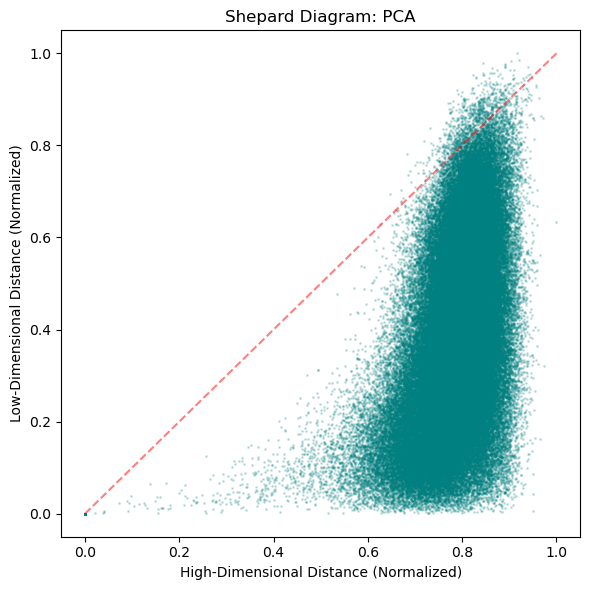

Saved: ../results/shepard_diagrams/sentence-transformers/shepard_rcv1_pca.png


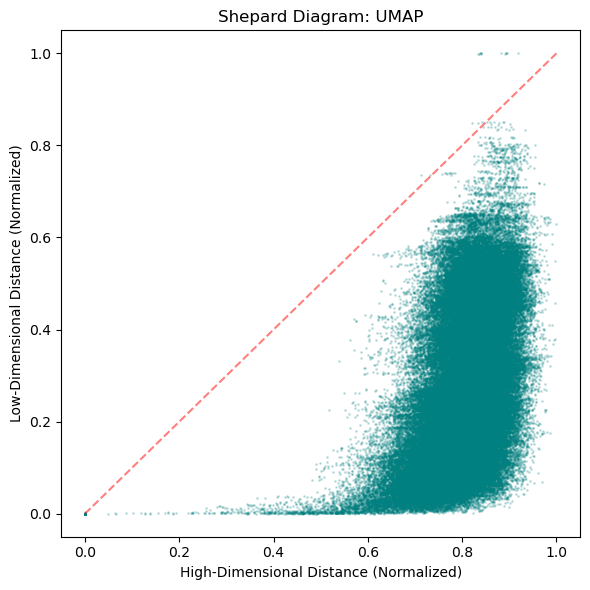

Saved: ../results/shepard_diagrams/sentence-transformers/shepard_rcv1_umap.png


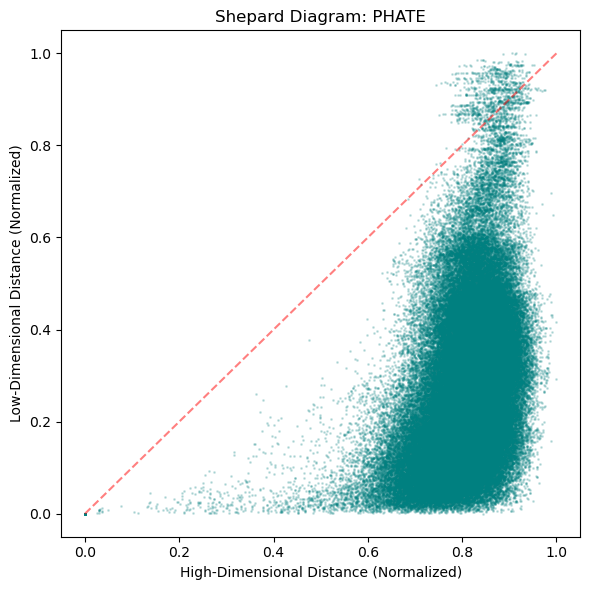

Saved: ../results/shepard_diagrams/sentence-transformers/shepard_rcv1_phate.png


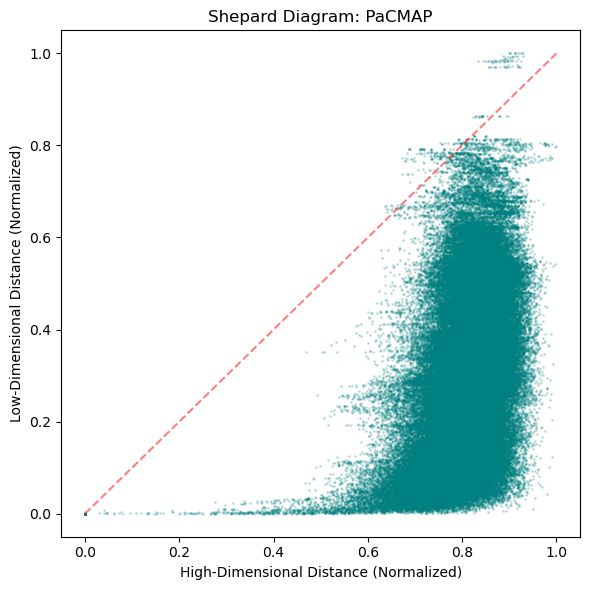

Saved: ../results/shepard_diagrams/sentence-transformers/shepard_rcv1_pacmap.png


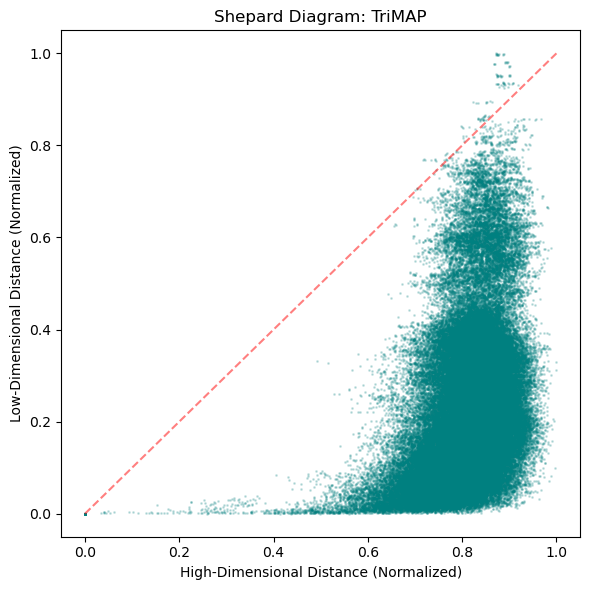

Saved: ../results/shepard_diagrams/sentence-transformers/shepard_rcv1_trimap.png


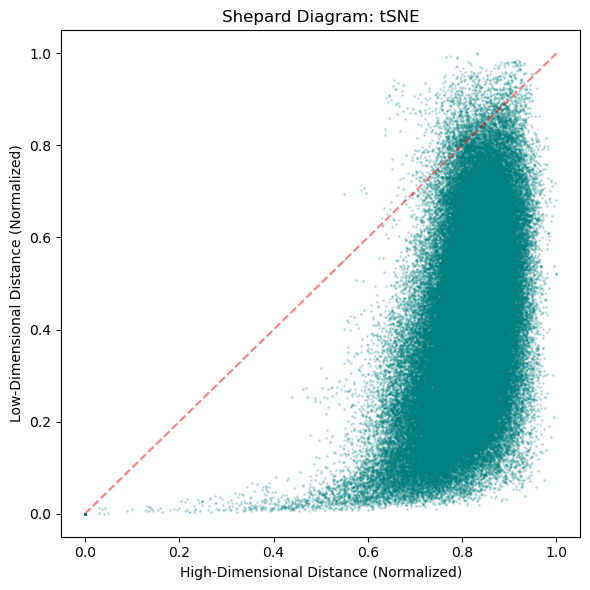

Saved: ../results/shepard_diagrams/sentence-transformers/shepard_rcv1_tsne.png


In [9]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), min(sample_size, len(x_high)), replace=False)

    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low  = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low  = d_low  / np.max(d_low)

    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()

    filename = os.path.join(shepard_dir, f"shepard_{dataset}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low_2d in reductions.items():
    f = plot_shepard(x_high_sub, x_low_2d, name)
    print(f"Saved: {f}")

## 6. Results

Loads viz metrics CSVs for both embedding models across all five benchmark datasets.

In [10]:
import os
import pandas as pd

minilm_dir = "../results/viz_metrics/sentence-transformers"
qwen_dir   = "../results/viz_metrics/Qwen"

def load_benchmark_csvs(results_dir):
    rows = []
    for f in sorted(os.listdir(results_dir)):
        if not f.startswith('viz_metrics_') or not f.endswith('.csv'):
            continue
        ds = f[len('viz_metrics_'):-len('.csv')]
        if '_hierarchy_' in ds:
            continue
        df = pd.read_csv(os.path.join(results_dir, f))
        df.insert(0, 'Dataset', ds)
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

minilm = load_benchmark_csvs(minilm_dir)
qwen   = load_benchmark_csvs(qwen_dir)

cols_mean = ['Dataset', 'Method', 'Trustworthiness_mean', 'Continuity_mean',
             'Spearman_Correlation_mean', 'DEMaP_mean']

# coerce ___ placeholders to NaN for display
for col in cols_mean[2:]:
    minilm[col] = pd.to_numeric(minilm[col], errors='coerce')
    qwen[col]   = pd.to_numeric(qwen[col],   errors='coerce')

print("=== MiniLM (all-MiniLM-L6-v2) ===")
display(minilm[cols_mean].rename(columns={
    'Trustworthiness_mean': 'Trust', 'Continuity_mean': 'Cont',
    'Spearman_Correlation_mean': 'Spearman', 'DEMaP_mean': 'DEMaP'
}).set_index(['Dataset','Method']).round(4))

print("\n=== Qwen (Qwen3-Embedding-0.6B) ===")
display(qwen[cols_mean].rename(columns={
    'Trustworthiness_mean': 'Trust', 'Continuity_mean': 'Cont',
    'Spearman_Correlation_mean': 'Spearman', 'DEMaP_mean': 'DEMaP'
}).set_index(['Dataset','Method']).round(4))

=== MiniLM (all-MiniLM-L6-v2) ===


Trust    Cont  Spearman   DEMaP
Dataset Method                                  
amazon  PCA     0.7392  0.8636    0.3639  0.3323
        UMAP    0.9114  0.9211    0.4077  0.5220
        PHATE   0.8022  0.9082    0.3441  0.4932
        PaCMAP  0.8645  0.9071    0.3571  0.4536
        TriMAP  0.8680  0.9128    0.3448  0.4416
        tSNE    0.9096  0.8549    0.2923  0.3345
arxiv   PCA     0.7607  0.8936    0.5018  0.4621
        UMAP    0.9440  0.9301    0.5318  0.6275
        PHATE   0.8165  0.9354    0.6377  0.7014
        PaCMAP  0.9103  0.9342    0.5770  0.6530
        TriMAP  0.8871  0.9429    0.5848  0.6504
        tSNE    0.9704  0.9310    0.4606  0.5205
dbpedia PCA     0.7118  0.8707    0.3033  0.2524
        UMAP    0.9749  0.9424    0.2744  0.5045
        PHATE   0.8816  0.9382    0.2641  0.5202
        PaCMAP  0.9600  0.9370    0.2360  0.4064
        TriMAP  0.9469  0.9456    0.2780  0.4915
        tSNE    0.5752  0.5585    0.0094 -0.0114
rcv1    PCA     0.7781  0.8913    0.3965  0.5048
        UMAP    0.9598  0.9426    0.4586  0.6601
        PHATE   0.8233  0.9063    0.3821  0.5745
        PaCMAP  0.9360  0.9333    0.4219  0.6321
        TriMAP  0.9357  0.9325    0.3723  0.5848
        tSNE    0.9560  0.9432    0.4597  0.6035
wos     PCA     0.7861  0.8940    0.5429  0.5663
        UMAP    0.9466  0.9319    0.4660  0.6208
        PHATE   0.8614  0.9395    0.5612  0.7213
        PaCMAP  0.9276  0.9441    0.5111  0.6660
        TriMAP  0.9071  0.9449    0.5350  0.6920
        tSNE    0.9751  0.9263    0.4292  0.5626


=== Qwen (Qwen3-Embedding-0.6B) ===


Trust    Cont  Spearman   DEMaP
Dataset Method                                  
amazon  PCA     0.7682  0.9006    0.4495  0.5186
        UMAP    0.9325  0.9336    0.4115  0.5564
        PHATE   0.8368  0.9342    0.4498  0.6284
        PaCMAP  0.9044  0.9306    0.4178  0.5491
        TriMAP  0.8979  0.9399    0.4405  0.5823
        tSNE    0.9550  0.9343    0.4516  0.5431
arxiv   PCA     0.7503  0.8776    0.5039  0.4659
        UMAP    0.9354  0.9210    0.4948  0.5997
        PHATE   0.8050  0.9177    0.5377  0.6205
        PaCMAP  0.9099  0.9178    0.5015  0.5785
        TriMAP  0.8860  0.9263    0.5078  0.5611
        tSNE    0.9599  0.8999    0.3656  0.4029
dbpedia PCA     0.7209  0.8802    0.3584  0.3434
        UMAP    0.9740  0.9346    0.2658  0.5033
        PHATE   0.8953  0.9454    0.3250  0.5720
        PaCMAP  0.9631  0.9453    0.3073  0.4262
        TriMAP  0.9568  0.9507    0.3013  0.5133
        tSNE    0.9660  0.9087    0.2500  0.3776
rcv1    PCA     0.7921  0.8937    0.5160  0.4907
        UMAP    0.9621  0.9373    0.4002  0.6743
        PHATE   0.8074  0.8925    0.3098  0.5793
        PaCMAP  0.9466  0.9350    0.3959  0.6029
        TriMAP  0.9404  0.9313    0.3602  0.6246
        tSNE    0.9621  0.9364    0.4244  0.5187
wos     PCA     0.7749  0.9092    0.4794  0.5668
        UMAP    0.9495  0.9388    0.4121  0.6409
        PHATE   0.8488  0.9424    0.4452  0.6909
        PaCMAP  0.9240  0.9434    0.4322  0.6282
        TriMAP  0.8957  0.9463    0.4343  0.6661
        tSNE    0.9752  0.9391    0.4181  0.6006

## 7. Discussion

**tSNE and UMAP lead on Trustworthiness across all datasets:** tSNE achieves 0.91–0.97 Trustworthiness, highest of all methods, followed closely by UMAP (0.91–0.96) and PaCMAP (0.86–0.95). TriMAP (0.87–0.94) is similar to PaCMAP. PHATE (0.80–0.86) and PCA (0.74–0.79) trail behind. The optimization-based methods pack similar points tightly in 2D, preserving local neighborhoods effectively.

**PHATE leads on DEMaP and Spearman for arXiv and WoS:** On arXiv (MiniLM), PHATE reaches Spearman 0.64 and DEMaP 0.70, the highest of any method on that dataset. On WoS (MiniLM), PHATE DEMaP is 0.72. PHATE's diffusion geometry captures the smooth topic manifold structure in academic text better than neighborhood-compression methods.

**tSNE has the lowest DEMaP despite the highest Trustworthiness:** tSNE DEMaP ranges 0.33–0.60 - lower than UMAP, PHATE, PaCMAP, and TriMAP - while its Trustworthiness is the highest. This confirms the known trade-off: tSNE aggressively preserves local clusters at the expense of global distance fidelity.

**UMAP leads on DEMaP for RCV1 and competes on WoS:** UMAP DEMaP ranges 0.52–0.68 across datasets, consistently above PCA. On RCV1 (MiniLM), UMAP DEMaP is 0.66, the highest on that dataset. TriMAP (0.44–0.69) and PaCMAP (0.45–0.67) are competitive with UMAP on most datasets but do not lead.

**WoS and arXiv produce the highest DEMaP scores overall:** Academic datasets (WoS, arXiv) have cleaner hierarchical topic structure than news (RCV1) or product reviews (Amazon), resulting in higher DEMaP across all methods. For MiniLM, Amazon shows the lowest DEMaP of all datasets (PCA: 0.33, tSNE: 0.33), suggesting its embedding structure is harder to preserve in 2D with MiniLM. Qwen Amazon DEMaP is substantially higher (PHATE: 0.63, UMAP: 0.56), consistent with Qwen's stronger performance on product text.

**Qwen3-Embedding-0.6B and MiniLM show different strengths by dataset:** On arXiv, MiniLM PHATE DEMaP (0.70) substantially exceeds Qwen (0.62). On Amazon, Qwen PHATE DEMaP (0.63) exceeds MiniLM (0.49). Neither model dominates across all datasets.

**Shepard diagrams complement the scalar metrics:** They show how each method distorts the full distance distribution. Even when scalar scores are similar across methods, the Shepard plots reveal distinct patterns in how each method handles different distance ranges.

**DBpedia shows the lowest Spearman across all datasets:** All methods on DBpedia achieve Spearman below 0.36 (MiniLM and Qwen), the lowest of any benchmark dataset, suggesting DBpedia's categorical structure does not project cleanly into 2D. MiniLM tSNE on DBpedia is a near-complete failure: Trustworthiness 0.58, Continuity 0.56, Spearman 0.009, DEMaP -0.01 - the only negative DEMaP observed across all datasets. This likely reflects tSNE's instability on the full 60,794-point dataset with many fine-grained categories (14 top-level classes, 3 hierarchy levels), where its local optimization fragments global structure entirely.

**Qwen tSNE on DBpedia behaves differently from MiniLM tSNE:** With Qwen embeddings, tSNE recovers a reasonable Trustworthiness (0.966) and positive DEMaP (0.378), unlike the MiniLM failure. This suggests the Qwen embedding geometry is more amenable to tSNE's local optimization on this dataset, even though Spearman (0.25) remains the lowest of all Qwen DBpedia methods - consistent with the general tSNE global-structure trade-off.

**PHATE leads DEMaP on DBpedia for both models:** PHATE MiniLM DEMaP (0.52) and Qwen DEMaP (0.57) are the highest of any method on DBpedia, consistent with its strength on datasets with manifold-like topic organization. UMAP is second (0.50 MiniLM, 0.50 Qwen). TriMAP Qwen (0.51) is also competitive.